# **REGRESION LOGISTICA ONE VS ALL**

Apellido y Nombre: Vasquez Caiza Juan Marcelo.

Carrera: Ingenieria de Sistemas.


In [211]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [212]:
import os

import numpy as np

from matplotlib import pyplot

from scipy import optimize

import pandas as pd

%matplotlib inline

# **Cargamos los datos**

Verificamos si el dataset presenta valores nulos y realizamos el preprocesamiento de los datos.

In [213]:
data = pd.read_csv('/content/drive/MyDrive/Inteligencia Artificial I/Datasets Trabajos/diabetes_012_health_indicators_BRFSS2021.csv', delimiter=',')
print('INFORMACION DE TIPO DE DATOS')
data.info()
print('\nDATOS VACIOS')
print(pd.isnull(data).sum())

INFORMACION DE TIPO DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236378 entries, 0 to 236377
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          236378 non-null  float64
 1   HighBP                236378 non-null  int64  
 2   HighChol              236378 non-null  float64
 3   CholCheck             236378 non-null  int64  
 4   BMI                   236378 non-null  float64
 5   Smoker                236378 non-null  float64
 6   Stroke                236378 non-null  float64
 7   HeartDiseaseorAttack  236378 non-null  float64
 8   PhysActivity          236378 non-null  int64  
 9   Fruits                236378 non-null  int64  
 10  Veggies               236378 non-null  int64  
 11  HvyAlcoholConsump     236378 non-null  int64  
 12  AnyHealthcare         236378 non-null  int64  
 13  NoDocbcCost           236378 non-null  float64
 14  GenHlth               2

Verificamos que nuestro dataset consta de 236378 filas y 22 columnas.

In [214]:
num_filas, num_columnas = data.shape
print('Numero de filas: ', num_filas)
print('Numero de columnas: ', num_columnas)
conteo_diabetes = data['Diabetes_012'].value_counts()
print(conteo_diabetes)

Numero de filas:  236378
Numero de columnas:  22
Diabetes_012
0.0    197191
2.0     33568
1.0      5619
Name: count, dtype: int64


Introducimos a input_layer_size el valor de 22 columnas (La entrada es de 22 contando x0) y el num_labels = 3 xq solamente existen 3 categorias de diabetes(Numero total de clases unicas).

In [215]:
input_layer_size  = 22

num_labels = 3

y =  data['Diabetes_012']
X = data.drop('Diabetes_012', axis=1)

m = y.size

print(f'Dimensiones de X (variables predictoras): {X.shape}')
print(f'Dimensiones de y (variable objetivo): {y.shape}')

Dimensiones de X (variables predictoras): (236378, 21)
Dimensiones de y (variable objetivo): (236378,)


# **Division de los Datos**

Dividimos los datos en 80% de entrenamiento y 20% de prueba, el parametro stratify permitira que la proporcion de clases en los conjuntos de entrenamiento y prueba se mantengan iguales.

In [216]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43, stratify=y)

Aplicamos normalizacion de Datos

In [217]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [218]:
X_train_norm, mu, sigma = featureNormalize(X_train)
X_test_norm = (X_test - mu) / sigma
m_test = len(X_test)

In [219]:
print(X_train)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_train_norm)

        HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
35157        0       0.0          1  30.0     0.0     0.0   
201637       0       0.0          1  27.0     0.0     0.0   
29978        0       0.0          1  27.0     0.0     0.0   
16760        1       0.0          1  30.0     0.0     0.0   
26379        1       1.0          1  34.0     0.0     0.0   
...        ...       ...        ...   ...     ...     ...   
24576        1       0.0          1  40.0     1.0     0.0   
196782       0       1.0          1  31.0     0.0     0.0   
141143       1       1.0          1  33.0     0.0     0.0   
51046        0       0.0          1  30.0     1.0     0.0   
161783       0       1.0          1  26.0     0.0     0.0   

        HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  ...  \
35157                    0.0             1       0        1  ...   
201637                   0.0             1       1        1  ...   
29978                    0.0             1       0        1  ..

Agregamos el termino de x0 a X

In [220]:
#X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
#X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

In [221]:
print("\n--- Datos con el término de intercepción ---")
print("Forma de X_train_final:", X_train_norm.shape)
print("Forma de X_test_final:", X_test_norm.shape)
print("Primeras 5 filas del DataFrame de entrenamiento con intercepción:")
print(X_train_norm[:5])


--- Datos con el término de intercepción ---
Forma de X_train_final: (189102, 21)
Forma de X_test_final: (47276, 21)
Primeras 5 filas del DataFrame de entrenamiento con intercepción:
          HighBP  HighChol  CholCheck       BMI    Smoker    Stroke  \
35157  -0.847985 -0.818272     0.1945  0.158802 -0.837624 -0.200526   
201637 -0.847985 -0.818272     0.1945 -0.299014 -0.837624 -0.200526   
29978  -0.847985 -0.818272     0.1945 -0.299014 -0.837624 -0.200526   
16760   1.179267 -0.818272     0.1945  0.158802 -0.837624 -0.200526   
26379   1.179267  1.222088     0.1945  0.769223 -0.837624 -0.200526   

        HeartDiseaseorAttack  PhysActivity    Fruits   Veggies  ...  \
35157              -0.307046      0.532047 -1.280201  0.455972  ...   
201637             -0.307046      0.532047  0.781127  0.455972  ...   
29978              -0.307046      0.532047 -1.280201  0.455972  ...   
16760              -0.307046      0.532047  0.781127 -2.193117  ...   
26379              -0.307046      

# **Vectorizacion de regresion logistica**

Se definen las funciones necesarias:

Sigmoid(z)-> Se calcula la sigmoide para convertir la salida de un modelo lineal en una probabilidad.

Si la entrada (z) es un número positivo muy grande, el resultado se acerca a 1.

Si la entrada (z) es un número negativo muy grande, el resultado se acerca a 0.

Si la entrada (z) es 0, el resultado es 0.5.

In [222]:
def sigmoid(z):

    return 1.0 / (1.0 + np.exp(-z))

In [223]:
def calcularCosto(theta, X, y):

    m = y.size

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [224]:
def descensoGradiente(theta, X, y, alpha, num_iters):

    m = y.shape[0]


    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

El siguiente codigo contiene la implementacion completa del costo y el gradiente pero con regularizacion, lambda_ es el parametro de regularizacion controla la penalizacion al costo y al gradiente.

In [225]:
def lrCostFunction(theta, X, y, lambda_):

    m = y.size


    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    temp = theta
    temp[0] = 0


    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X)

    grad = grad + (lambda_ / m) * temp

    return J, grad

El valor de lambda es importante por estos 2 puntos:

Si lambda es un numero grande:
*   El modelo es demasiado simple y no logra capturar la complejidad de los datos, lo que resulta en un alto error tanto en el conjunto de entrenamiento como en el de prueba.(underfitting)

Si lambda es un numero pequeño:
*   El modelo funciona muy bien en los datos de entrenamiento, pero falla al generalizar a datos nuevos y no vistos.(overfitting)



# **CLASIFICACION ONE VS ALL**

El clasificador que permite anejjar solo 2 categorias a la vez.

In [226]:
def OneVsAll(X, y, num_labels, lambda_):
  alpha = 0.01
  num_iters = 2000

  m, n = X.shape
  all_theta = np.zeros((num_labels, n + 1))

  # Agrega unos a la matriz X
  X = np.concatenate([np.ones((m, 1)), X], axis=1)

  for c in np.arange(num_labels):
      initial_theta = np.zeros(n + 1)

      y_actual = np.where(y == c, 1, 0)

      theta, J_history = descensoGradiente(initial_theta, X, y_actual, alpha, num_iters)

      all_theta[c] = theta


      pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
      pyplot.xlabel('Numero de iteraciones')
      pyplot.ylabel('Costo J')

  return all_theta

Lo mismo pero aca se usa la funcion optimize.minimize de SciPy en lugra de la funcion descensoGradiente

In [227]:
def OneVsAllOM(X, y, num_labels, lambda_):


    m, n = X.shape

    all_theta = np.zeros((num_labels, n + 1))

    # Agrega unos a la matriz X
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        options = {'maxiter': 10}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                options=options)

        all_theta[c] = res.x


    return all_theta

Una vez conseguidas las thetas para cada categoria, predice la clase de cada muestra.

In [228]:
def predictOneVsAll(all_theta, X):

    m = X.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)

    return p

# **REALIZAMOS EL ENTRENAMIENTO**

(3, 22)


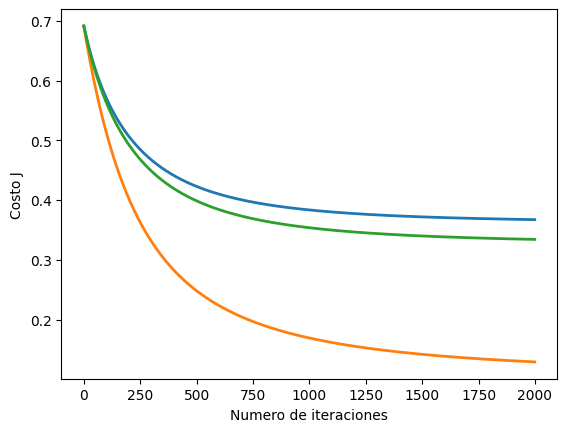

In [229]:
lambda_ = 0.1
all_theta = OneVsAll(X_train_norm, y_train, num_labels, lambda_)
print(all_theta.shape)

In [230]:
print(all_theta)

[[ 1.76890062e+00 -2.86291325e-01 -2.42040835e-01 -1.13810061e-01
  -3.10021166e-01  1.99279400e-02 -3.43465007e-02 -8.89527267e-02
   6.56171502e-02  6.05752366e-03  1.22464245e-02  1.05368215e-01
  -2.18832853e-02 -1.07584723e-03 -3.27064801e-01  2.48020939e-02
   1.96187084e-03 -7.65987059e-02 -8.84482469e-02 -2.48359144e-01
   4.89549199e-02  1.09728003e-01]
 [-2.66172876e+00  3.31753778e-02  5.82197092e-02  2.07950624e-02
   6.63329142e-02 -2.24302354e-03 -4.82094914e-03 -4.46434565e-03
   2.62602602e-04 -4.60119394e-03 -4.19344155e-03 -1.02904210e-02
  -4.67227986e-03  1.62985385e-02  4.22548248e-02  1.00795555e-02
  -3.95915857e-03  1.32134651e-02 -1.40267906e-04  4.37558417e-02
  -2.15432309e-02 -3.77300391e-02]
 [-1.91458784e+00  2.91299793e-01  2.20566888e-01  1.02535505e-01
   2.81971801e-01 -1.65460464e-02  4.02879791e-02  9.98621183e-02
  -7.51721359e-02 -4.25058481e-03 -1.22104260e-02 -1.04317575e-01
   2.88198509e-02 -1.07373196e-02  3.17074268e-01 -3.27721185e-02
   7.6

# **REALIZAMOS PREDICCIONES**

In [231]:
pred_train = predictOneVsAll(all_theta, X_train_norm)
print('Precision del conjunto de entrenamiento: {:.2f}%'.format(np.mean(pred_train == y_train) * 100))


pred_test = predictOneVsAll(all_theta, X_test_norm)
print('Precision del conjunto de prueba: {:.2f}%'.format(np.mean(pred_test == y_test) * 100))

Precision del conjunto de entrenamiento: 83.92%
Precision del conjunto de prueba: 83.91%


Como podemos ver la diferencia de la precision entre ambos conjunto de datos no es grande.